# What can be done next?
- permutation of bases

- change number of features deleted

- change model

- change metric

- extract other homological invariant

In [27]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from gtda.diagrams import PairwiseDistance
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy
from data import load_data
plt.rcParams['font.family'] = 'DejaVu Sans Mono'


def tda_dist(ser_1, ser_2, metric='bottleneck'):
    pdist = PairwiseDistance(metric=metric)
    index = ser_1.index
    ser_1 = ser_1.values.reshape(ser_1.shape[0], 1, -1, 2)
    ser_1 = np.pad(ser_1, pad_width=((0, 0), (0, 0), (0, 0), (0, 1)), constant_values=1)
    ser_2 = ser_2.values.reshape(ser_2.shape[0], 1, -1, 2)
    ser_2 = np.pad(ser_2, pad_width=((0, 0), (0, 0), (0, 0), (0, 1)), constant_values=1)
    result = [pdist.fit(dgm_1).transform(dgm_2)[0, 0] for dgm_1, dgm_2 in zip(ser_1, ser_2)]
    return pd.Series(result, index=index)


def parse_entropy_sum(msg):
    return sum(map(entropies.__getitem__, msg.split(',')))


df = load_data()
entropies = dict()
for i, (key, col) in enumerate(df.iteritems()):
    if i < 3: continue
    entropies[key] = entropy(col.value_counts())

In [3]:
from scipy.stats import pearsonr

# Performance before and after

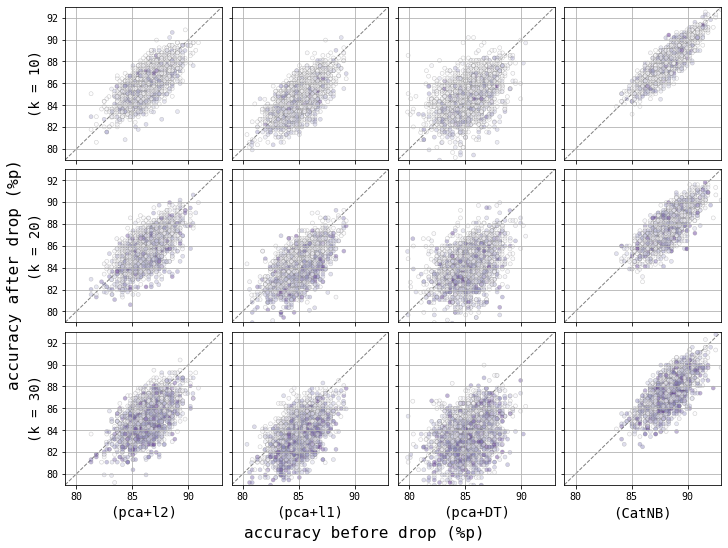

In [40]:
df_result = pd.read_csv('../output/20230517_exp_log_w_names_500.csv')
models = ['pca+l2', 'pca+l1', 'pca+DT', 'CatNB']
n_drops = [10, 20, 30]
ag_only = False

nrows = len(n_drops); ncols = len(models)
fig, axs = plt.subplots(
    nrows=nrows, ncols=ncols, sharex=True, sharey=True, 
    figsize=(2.5*ncols, 2.5*nrows), layout='constrained'
)
for j, model_name in enumerate(models):
    for i, n_drop in enumerate(n_drops):
        current_mask = (df_result['A&G_only'] == ag_only) & (df_result['n_drop'] == n_drop) & (df_result['model'] == model_name)
        grouper = df_result.loc[current_mask, 'split_id']
        df_current = df_result[current_mask]

        persistence_control = df_current.loc[:, 'birth_control_0':'death_control_9']
        persistence_modified = df_current.loc[:, 'birth_modified_0':'death_modified_9']
        dgm_dist = tda_dist(persistence_modified, persistence_control, metric='silhouette')
        acc_before = df_current['accuracy_control']
        acc_after = df_current['accuracy_modified']

        corr_x = acc_before; corr_y = acc_after; color = dgm_dist
        # corr_x = corr_x.groupby(grouper).agg('mean')
        # corr_y = corr_y.groupby(grouper).agg('mean')
        # color = color.groupby(grouper).agg('mean')

        ax = axs[i, j]
        ax.scatter(
            x=corr_x, y=corr_y, 
            s=16, alpha=0.4, c=color, 
            linewidths=0.5, edgecolors='grey',
            cmap='Purples'
        )
        ax.plot([79, 93], [79, 93], color='grey', linewidth=1, linestyle='--', zorder=0)
        ax.grid()
        if i == nrows-1:
            ax.set_xlabel(f'({model_name})', fontsize=14)
        if j == 0:
            ax.set_ylabel(f'(k = {n_drop})', fontsize=14)
fig.supxlabel('accuracy before drop (%p)', fontsize=16)
fig.supylabel('accuracy after drop (%p)', fontsize=16)
[0, 100]
#hardcode
ax.set_xlim([79, 93]); ax.set_ylim([79, 93])

plt.show(); plt.close()

# Change of shape vs. Change of performance

In [6]:
from scipy.stats import spearmanr, kendalltau

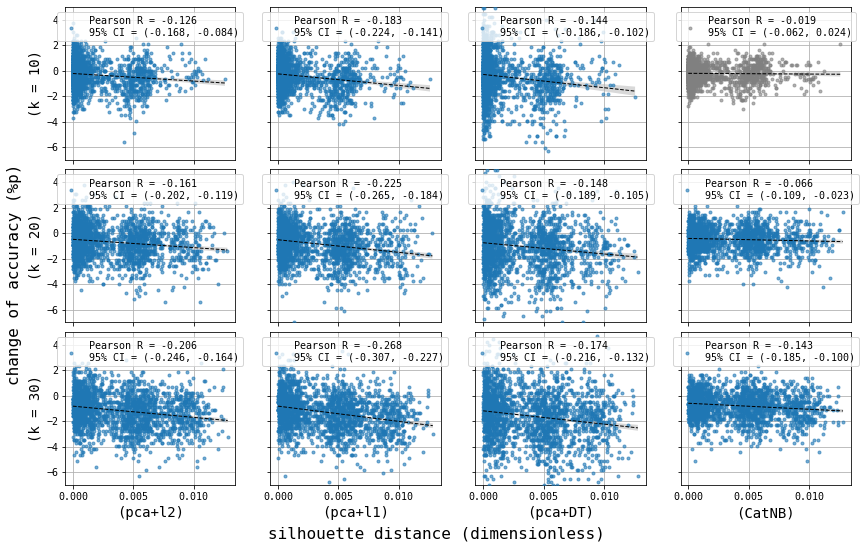

In [45]:
df_result = pd.read_csv('../output/20230517_exp_log_w_names_500.csv')
models = ['pca+l2', 'pca+l1', 'pca+DT', 'CatNB']
n_drops = [10, 20, 30]
# models = models[:2]; n_drops = n_drops[:2]
ag_only = False

nrows = len(n_drops); ncols = len(models)
fig, axs = plt.subplots(
    nrows=nrows, ncols=ncols, sharex=True, sharey=True, 
    figsize=(3*ncols, 2.5*nrows), layout='constrained'
)
for j, model_name in enumerate(models):
    for i, n_drop in enumerate(n_drops):
        current_mask = (df_result['A&G_only'] == ag_only) & (df_result['n_drop'] == n_drop) & (df_result['model'] == model_name)
        grouper = df_result.loc[current_mask, 'split_id']
        df_current = df_result[current_mask]

        persistence_control = df_current.loc[:, 'birth_control_0':'death_control_9']
        persistence_modified = df_current.loc[:, 'birth_modified_0':'death_modified_9']

        # dgm_dist = df_result.loc[current_mask, 'birth_modified_0'] - df_result.loc[current_mask, 'birth_control_0']
        dgm_dist = tda_dist(persistence_modified, persistence_control, metric='silhouette')
        acc_change = df_current['accuracy_modified'] - df_current['accuracy_control']
        entropy_change = df_current['dropped_loci'].apply(parse_entropy_sum)


        corr_x = dgm_dist
        # corr_x = df_current['Hausdorff_distance']
        # corr_x = entropy_change

        corr_y = acc_change

        # corr_x = corr_x.groupby(grouper).agg('mean')
        # corr_y = corr_y.groupby(grouper).agg('mean')

        corr_result = pearsonr(corr_x, corr_y, alternative='two-sided')
        r_val = corr_result.statistic
        p_val = corr_result.pvalue * 2
        conf_interval = corr_result.confidence_interval().low, corr_result.confidence_interval().high
        is_significant = conf_interval[1] < 0

        spearman_result = spearmanr(corr_x, corr_y, alternative='two-sided')
        kendall_result = kendalltau(corr_x, corr_y, alternative='two-sided')

        ax = axs[i, j]
        sns.regplot(
            x=corr_x, y=corr_y,
            seed=42,
            label=f'Pearson R = {r_val:.3f}\n95% CI = ({conf_interval[0]:.3f}, {conf_interval[1]:.3f})',
            # label=f'Pearson R = {r_val:.3f}\n95% CI = ({conf_interval[0]:.3f}, {conf_interval[1]:.3f})' + \
            #     f'\nSpearman R = {spearman_result.correlation:.3f} (p-value={spearman_result.pvalue:.3f})' + \
            #     f'\nKendall τ = {kendall_result.correlation:.3f} (p-value={kendall_result.pvalue:.3f})',
            color='C0' if is_significant else 'grey',
            scatter_kws={
                's': 9,
                'alpha': 0.6,
                'zorder': 3
            },
            line_kws={
                'linestyle': '--',
                'linewidth': 1,
                'color': 'black',
                'zorder': 4,
            },
            ax=ax,
        )
        ax.grid()
        ax.legend(loc='upper center') #, labelcolor='black' if is_significant else 'grey')
        if i == nrows-1:
            ax.set_xlabel(f'({model_name})', fontsize=14)
        if j == 0:
            ax.set_ylabel(f'(k = {n_drop})', fontsize=14)
fig.supxlabel('silhouette distance (dimensionless)', fontsize=16)
fig.supylabel('change of accuracy (%p)', fontsize=16)

#hardcode
ax.set_ylim(-7, 5)

plt.show(); plt.close()